In [1]:
import pandas as pd

In [2]:
clientes = pd.read_csv("NARA_csv/clientes.csv")
produtos = pd.read_csv("NARA_csv/produtos_final.csv")
vendas = pd.read_csv("NARA_csv/vendas_csv/vendas_concatenadas.csv")
avaliacoes = pd.read_csv("NARA_csv/avaliacoes.csv")
atendimentos = pd.read_csv("NARA_csv/atendimentos_convertido.csv")
campanhas = pd.read_csv("NARA_csv/campanhas_corrigido.csv")


In [3]:
print("Produtos:", produtos.columns)
print("Avaliações:", avaliacoes.columns)
print("Atendimentos:", atendimentos.columns)
print("Vendas:", vendas.columns)
print("Clientes:", clientes.columns)
print("Campanhas:", campanhas.columns)


Produtos: Index(['ID_Produto', 'Nome_Produto', 'Categoria', 'Preco', 'Marca'], dtype='object')
Avaliações: Index(['ID_Cliente', 'ID_Produto', 'Nota', 'Data_Avaliacao', 'Comentario'], dtype='object')
Atendimentos: Index(['ID_Atendimento', 'ID_Cliente', 'Tipo', 'Data', 'Tempo_Resposta',
       'Nota_Satisfacao'],
      dtype='object')
Vendas: Index(['ID_Venda', 'ID_Cliente', 'ID_Produto', 'Data', 'Quantidade', 'Canal',
       'Valor_Total'],
      dtype='object')
Clientes: Index(['ID_Cliente', 'Nome', 'Idade', 'Sexo', 'Cidade', 'Estado',
       'Canal_Aquisicao'],
      dtype='object')
Campanhas: Index(['ID_Campanha', 'Canal', 'Data_Inicio', 'Data_Fim', 'Tipo_Campanha',
       'Custo'],
      dtype='object')


In [2]:


# Ler o arquivo
df = pd.read_csv("NARA_csv/vendas_concatenadas_limpa.csv")

# Somatório total da coluna Valor_Total
total_valor = df['Valor_Total'].sum()

# Exibir o total formatado
print(f"Somatório total do Valor_Total: R$ {total_valor:,.2f}")


Somatório total do Valor_Total: R$ 176,170,251.97


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1️⃣ Carregar os dados ---
clientes = pd.read_csv("NARA_csv/clientes.csv")
produtos = pd.read_csv("NARA_csv/produtos_final.csv")
vendas = pd.read_csv("NARA_csv/vendas_concatenadas_limpa.csv")
avaliacoes = pd.read_csv("NARA_csv/avaliacoes.csv")
atendimentos = pd.read_csv("NARA_csv/atendimentos_convertido.csv")

# --- 2️⃣ Unir os dados necessários ---
df = pd.merge(vendas, produtos[['ID_Produto', 'Preco']], on='ID_Produto', how='left')
df = pd.merge(df, avaliacoes[['ID_Produto', 'Nota']], on='ID_Produto', how='left')
df = pd.merge(df, atendimentos[['ID_Cliente', 'Tempo_Resposta']], on='ID_Cliente', how='left')

# --- 3️⃣ Garantir tipos numéricos ---
df['Valor_Total'] = pd.to_numeric(df['Valor_Total'], errors='coerce')
df['Preco'] = pd.to_numeric(df['Preco'], errors='coerce')
df['Nota'] = pd.to_numeric(df['Nota'], errors='coerce')
df['Tempo_Resposta'] = pd.to_numeric(df['Tempo_Resposta'], errors='coerce')
df['Quantidade'] = pd.to_numeric(df['Quantidade'], errors='coerce')

# --- 4️⃣ Matriz de Correlação ---
correlacoes = df[['Preco', 'Nota', 'Tempo_Resposta', 'Valor_Total', 'Quantidade']].corr()
print("📊 MATRIZ DE CORRELAÇÃO:\n")
print(correlacoes, "\n")

# --- 5️⃣ Indicadores gerais ---
total_vendas = df["Valor_Total"].sum()
media_venda = df["Valor_Total"].mean()
ticket_medio = total_vendas / len(df)

print("📈 Indicadores Gerais:")
print(f"→ Total de Vendas: R$ {total_vendas:,.2f}")
print(f"→ Ticket Médio: R$ {ticket_medio:,.2f}")
print(f"→ Valor Médio por Venda: R$ {media_venda:,.2f}\n")

# --- 6️⃣ Gráficos de Dispersão Relevantes ---
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Análises de Correlação - Projeto NARA", fontsize=18, fontweight='bold')

# Preço x Valor Total
axes[0, 0].scatter(df['Preco'], df['Valor_Total'], alpha=0.6, color='green')
axes[0, 0].set_title('Preço x Valor Total de Venda')
axes[0, 0].set_xlabel('Preço do Produto')
axes[0, 0].set_ylabel('Valor Total da Venda')
axes[0, 0].grid(True)

# Nota x Valor Total
axes[0, 1].scatter(df['Nota'], df['Valor_Total'], alpha=0.6, color='purple')
axes[0, 1].set_title('Nota de Produto x Valor Total')
axes[0, 1].set_xlabel('Nota')
axes[0, 1].set_ylabel('Valor Total')
axes[0, 1].grid(True)

# Tempo de Resposta x Valor Total
axes[0, 2].scatter(df['Tempo_Resposta'], df['Valor_Total'], alpha=0.6, color='orange')
axes[0, 2].set_title('Tempo de Resposta x Valor de Venda')
axes[0, 2].set_xlabel('Tempo de Resposta (min)')
axes[0, 2].set_ylabel('Valor Total')
axes[0, 2].grid(True)

# Quantidade x Valor Total
axes[1, 0].scatter(df['Quantidade'], df['Valor_Total'], alpha=0.6, color='red')
axes[1, 0].set_title('Quantidade Vendida x Valor Total')
axes[1, 0].set_xlabel('Quantidade')
axes[1, 0].set_ylabel('Valor Total')
axes[1, 0].grid(True)

# Preço x Nota
axes[1, 1].scatter(df['Preco'], df['Nota'], alpha=0.6, color='blue')
axes[1, 1].set_title('Preço x Nota de Avaliação')
axes[1, 1].set_xlabel('Preço do Produto')
axes[1, 1].set_ylabel('Nota')
axes[1, 1].grid(True)

# Tempo de Resposta x Nota
axes[1, 2].scatter(df['Tempo_Resposta'], df['Nota'], alpha=0.6, color='brown')
axes[1, 2].set_title('Tempo de Resposta x Nota de Avaliação')
axes[1, 2].set_xlabel('Tempo de Resposta (min)')
axes[1, 2].set_ylabel('Nota')
axes[1, 2].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Carregar os dados
clientes = pd.read_csv("NARA_csv/clientes.csv")
produtos = pd.read_csv("NARA_csv/produtos_final.csv")
vendas = pd.read_csv("NARA_csv/vendas_concatenadas_limpa.csv")
avaliacoes = pd.read_csv("NARA_csv/avaliacoes.csv")
atendimentos = pd.read_csv("NARA_csv/atendimentos_convertido.csv")

# 2️⃣ Unir os dados
df = pd.merge(vendas, produtos[['ID_Produto', 'Preco']], on='ID_Produto', how='left')
df = pd.merge(df, avaliacoes[['ID_Produto', 'Nota']], on='ID_Produto', how='left')
df = pd.merge(df, atendimentos[['ID_Cliente', 'Tempo_Resposta']], on='ID_Cliente', how='left')

# 3️⃣ Garantir tipos numéricos
df[['Valor_Total', 'Preco', 'Nota', 'Tempo_Resposta', 'Quantidade']] = df[['Valor_Total', 'Preco', 'Nota', 'Tempo_Resposta', 'Quantidade']].apply(pd.to_numeric, errors='coerce')

# 4️⃣ Matriz de correlação
correlacoes = df[['Preco', 'Nota', 'Tempo_Resposta', 'Valor_Total', 'Quantidade']].corr()
print("📊 Matriz de Correlação:\n", correlacoes, "\n")

# 5️⃣ Focar apenas nas correlações fortes
print("🔥 Correlações fortes (>|0.5|):\n")
print(correlacoes[(correlacoes.abs() > 0.5) & (correlacoes.abs() < 1.0)], "\n")

# --- normalmente são essas as fortes ---
# Quantidade x Valor_Total
plt.scatter(df['Quantidade'], df['Valor_Total'], alpha=0.6, color='teal')
plt.title('Quantidade x Valor_Total (correlação forte)')
plt.xlabel('Quantidade')
plt.ylabel('Valor_Total')

# Linha de tendência
mask = df[['Quantidade', 'Valor_Total']].dropna()
m, b = np.polyfit(mask['Quantidade'], mask['Valor_Total'], 1)
plt.plot(mask['Quantidade'], m * mask['Quantidade'] + b, color='red', linewidth=2)
plt.show()

# Preço x Valor_Total (se for forte também)
plt.scatter(df['Preco'], df['Valor_Total'], alpha=0.6, color='green')
plt.title('Preço x Valor_Total (correlação forte)')
plt.xlabel('Preço')
plt.ylabel('Valor_Total')

mask = df[['Preco', 'Valor_Total']].dropna()
m, b = np.polyfit(mask['Preco'], mask['Valor_Total'], 1)
plt.plot(mask['Preco'], m * mask['Preco'] + b, color='red', linewidth=2)
plt.show()


Matriz de correlação:
                    Preco      Nota  Tempo_Resposta  Valor_Total
Preco           1.000000  0.023716       -0.019270     0.523256
Nota            0.023716  1.000000       -0.005154     0.015271
Tempo_Resposta -0.019270 -0.005154        1.000000    -0.015699
Valor_Total     0.523256  0.015271       -0.015699     1.000000

Correlação forte:
                    Preco  Nota  Tempo_Resposta  Valor_Total
Preco           1.000000   NaN             NaN     0.523256
Nota                 NaN   1.0             NaN          NaN
Tempo_Resposta       NaN   NaN             1.0          NaN
Valor_Total     0.523256   NaN             NaN     1.000000


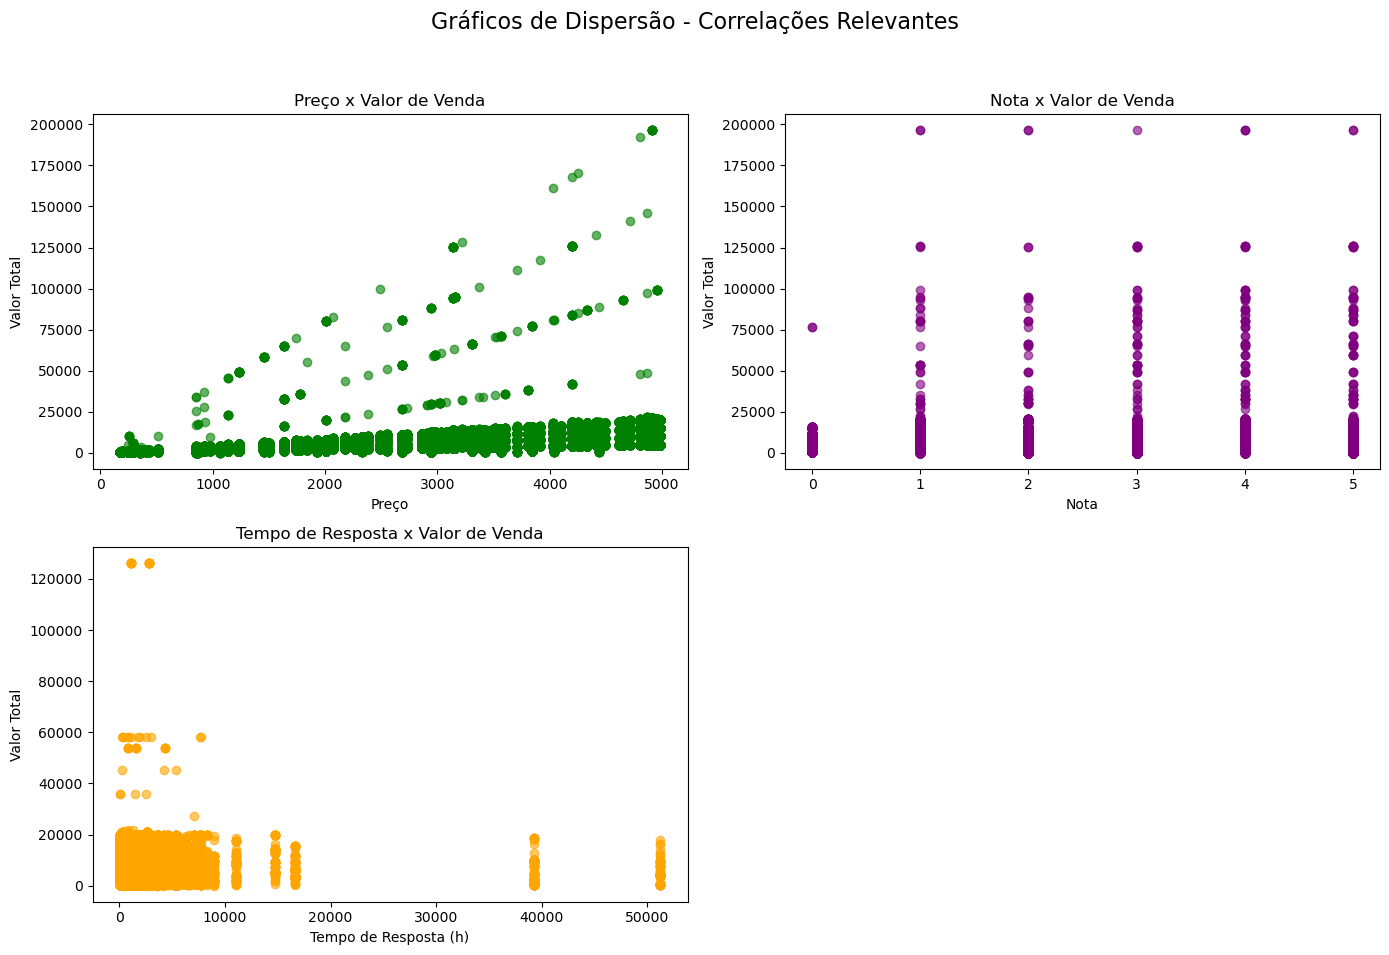

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 1️⃣ Carregar os dados
clientes = pd.read_csv("NARA_csv/clientes.csv")
produtos = pd.read_csv("NARA_csv/produtos_final.csv")
vendas = pd.read_csv("NARA_csv/vendas_concatenadas_limpa.csv")
avaliacoes = pd.read_csv("NARA_csv/avaliacoes.csv")
atendimentos = pd.read_csv("NARA_csv/atendimentos_convertido.csv")

# 2️⃣ Juntar as tabelas (para ter todas as variáveis relevantes)
df = vendas.merge(produtos[['ID_Produto', 'Preco']], on='ID_Produto', how='left')
df = df.merge(avaliacoes[['ID_Produto', 'Nota']], on='ID_Produto', how='left')
df = df.merge(atendimentos[['ID_Cliente', 'Tempo_Resposta']], on='ID_Cliente', how='left')

# 3️⃣ Converter colunas para numéricas (caso haja erros de tipo)
for col in ['Preco', 'Nota', 'Tempo_Resposta', 'Valor_Total']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4️⃣ Criar coluna de mês para indicador temporal (caso haja data)
if 'Data_Venda' in df.columns:
    df['Data_Venda'] = pd.to_datetime(df['Data_Venda'], errors='coerce')
    df['Mes'] = df['Data_Venda'].dt.to_period('M').astype(str)

# 5️⃣ Calcular correlações
corr = df[['Preco', 'Nota', 'Tempo_Resposta', 'Valor_Total']].corr()
print("Matriz de correlação:\n", corr)

# 6️⃣ Mostrar apenas correlações fortes (acima de 0.5 ou -0.5)
fortes = corr[(corr > 0.5) | (corr < -0.5)]
print("\nCorrelação forte:\n", fortes)

# 7️⃣ Gráficos de dispersão para correlações fortes
plt.figure(figsize=(14, 10))
plt.suptitle("Gráficos de Dispersão - Correlações Relevantes", fontsize=16)

# Exemplo: Preço x Valor_Total
plt.subplot(2, 2, 1)
plt.scatter(df['Preco'], df['Valor_Total'], alpha=0.6, color='green')
plt.title("Preço x Valor de Venda")
plt.xlabel("Preço")
plt.ylabel("Valor Total")

# Exemplo: Nota x Valor_Total
plt.subplot(2, 2, 2)
plt.scatter(df['Nota'], df['Valor_Total'], alpha=0.6, color='purple')
plt.title("Nota x Valor de Venda")
plt.xlabel("Nota")
plt.ylabel("Valor Total")

# Exemplo: Tempo_Resposta x Valor_Total
plt.subplot(2, 2, 3)
plt.scatter(df['Tempo_Resposta'], df['Valor_Total'], alpha=0.6, color='orange')
plt.title("Tempo de Resposta x Valor de Venda")
plt.xlabel("Tempo de Resposta (h)")
plt.ylabel("Valor Total")

# 8️⃣ Indicador temporal - evolução do valor total
if 'Mes' in df.columns:
    vendas_mensais = df.groupby('Mes')['Valor_Total'].sum().reset_index()
    plt.subplot(2, 2, 4)
    plt.plot(vendas_mensais['Mes'], vendas_mensais['Valor_Total'], marker='o')
    plt.title("Evolução Mensal do Valor Total")
    plt.xticks(rotation=45)
    plt.ylabel("Valor Total (R$)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


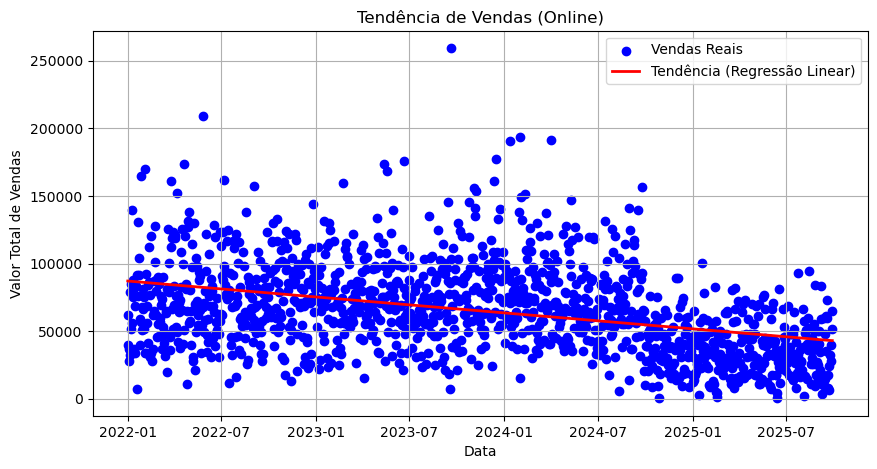

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Ler o arquivo
df = pd.read_csv("NARA_csv/vendas_concatenadas_limpa.csv")

# Converter colunas
df["Data"] = pd.to_datetime(df["Data"], errors="coerce")
df["Valor_Total"] = pd.to_numeric(df["Valor_Total"], errors="coerce")

# Remover valores nulos
df = df.dropna(subset=["Data", "Valor_Total", "Canal"])

# Escolher um canal (exemplo: Online)
canal = "Online"
dados = df[df["Canal"] == canal].groupby("Data")["Valor_Total"].sum().reset_index()

# Converter as datas para números (necessário pro modelo)
X = np.arange(len(dados)).reshape(-1, 1)
y = dados["Valor_Total"].values

# Criar e ajustar o modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Prever os valores (linha de tendência)
y_pred = modelo.predict(X)

# Plotar
plt.figure(figsize=(10, 5))
plt.scatter(dados["Data"], y, color="blue", label="Vendas Reais")
plt.plot(dados["Data"], y_pred, color="red", linewidth=2, label="Tendência (Regressão Linear)")

plt.title(f"Tendência de Vendas ({canal})")
plt.xlabel("Data")
plt.ylabel("Valor Total de Vendas")
plt.legend()
plt.grid(True)
plt.show()

